In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("AusApparalSales4thQrt2020.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [3]:
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [4]:
df["Norm_sales"]=(df["Sales"]-df["Sales"].min())/(df["Sales"].max()-df["Sales"].min())

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

df["Norm_unit"]=scaler.fit_transform(df[["Unit"]])
df.head()

,Date,Time,State,Group,Unit,Sales,Norm_sales,Norm_unit
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873


In [6]:
Sales_groups=df.groupby(df["Group"])["Sales"].sum().sort_values(ascending=False)
Sales_groups

Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

In [7]:
buys_group=df.groupby(df["Group"])["Unit"].sum().sort_values(ascending=False)
buys_group

Group
Men        34300
Women      34177
Kids       34029
Seniors    33615
Name: Unit, dtype: int64

In [8]:
buys_time=df.groupby(df["Time"])["Unit"].sum().sort_values(ascending=False)
buys_time

Time
Morning      45683
Afternoon    45603
Evening      44835
Name: Unit, dtype: int64

In [9]:
buys_time_sales=df.groupby(df["Time"])["Sales"].sum().sort_values(ascending=False)
buys_time_sales

Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64

In [10]:
state_sales=df.groupby(df["State"])["Sales"].sum().sort_values(ascending=False)
state_sales

State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

In [11]:
state_units=df.groupby(df["State"])["Sales"].sum().sort_values(ascending=False)
state_units

State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

In [12]:
df["Unit"].describe()

count    7560.000000
mean       18.005423
std        12.901403
min         2.000000
25%         8.000000
50%        14.000000
75%        26.000000
max        65.000000
Name: Unit, dtype: float64

In [13]:
df["Sales"].describe()

count      7560.000000
mean      45013.558201
std       32253.506944
min        5000.000000
25%       20000.000000
50%       35000.000000
75%       65000.000000
max      162500.000000
Name: Sales, dtype: float64

In [14]:
from scipy import stats

mode_sales = stats.mode(df["Sales"], keepdims=True)
mode_units = stats.mode(df["Unit"], keepdims=True)
print("Mode Sales:", mode_sales.mode[0])
print("Mode Units:", mode_units.mode[0])

Mode Sales: 22500
Mode Units: 9


In [15]:
highes_group= Sales_groups.idxmax()
print("highes_group :",highes_group)
lowest_group=Sales_groups.idxmin()
print("lowest_group :",lowest_group)

highes_group :  Men
lowest_group :  Seniors


In [16]:
max_sales = df["Sales"].max()
min_sales = df["Sales"].min()

print("Highest Sales Value:", max_sales)
print("Lowest Sales Value:", min_sales)

Highest Sales Value: 162500
Lowest Sales Value: 5000


In [17]:
df.columns = df.columns.str.strip()

In [18]:
print(df.columns.tolist())

['Date', 'Time', 'State', 'Group', 'Unit', 'Sales', 'Norm_sales', 'Norm_unit']


In [19]:
# Clean column names (safe step)
df.columns = df.columns.str.strip()

# Convert to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set index (IMPORTANT: pass column name, not df["Date"])
df.set_index("Date", inplace=True)

print(df.head())

                  Time State     Group  Unit  Sales  Norm_sales  Norm_unit
Date                                                                      
2020-10-01     Morning    WA      Kids     8  20000    0.095238   0.095238
2020-10-01     Morning    WA       Men     8  20000    0.095238   0.095238
2020-10-01     Morning    WA     Women     4  10000    0.031746   0.031746
2020-10-01     Morning    WA   Seniors    15  37500    0.206349   0.206349
2020-10-01   Afternoon    WA      Kids     3   7500    0.015873   0.015873


In [20]:
weekly_sales = df["Sales"].resample("W").sum()
print(weekly_sales.head())

Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
Freq: W-SUN, Name: Sales, dtype: int64


In [21]:
monthly_sales=df["Sales"].resample("ME").sum()
print(monthly_sales)

Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64


In [22]:
quarterly_sales = df["Sales"].resample("QE").sum()
print(quarterly_sales)

Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64


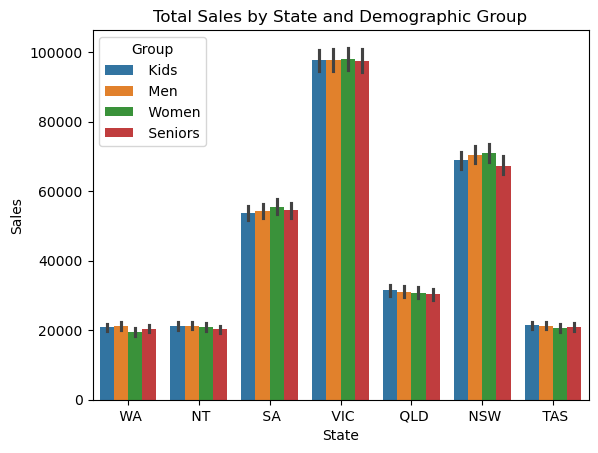

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x="State",y="Sales",hue="Group",data=df)
plt.title("Total Sales by State and Demographic Group")
plt.show()

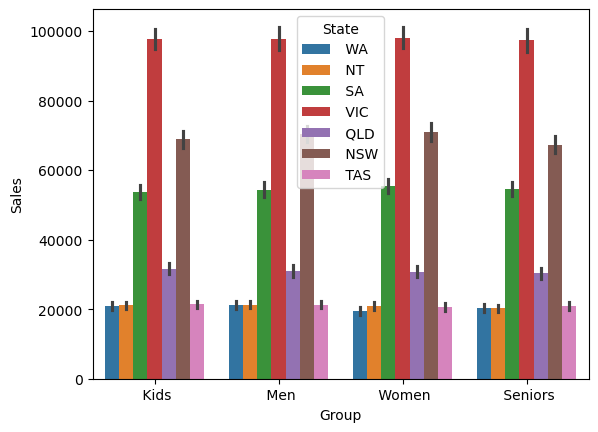

In [24]:
sns.barplot(x="Group",y="Sales",hue="State",data=df)
plt.show()

In [29]:
time_sales = df.groupby("Time")["Sales"].sum().reset_index()
print(time_sales)

         Time      Sales
0   Afternoon  114007500
1     Evening  112087500
2     Morning  114207500


In [30]:
peak=time_sales.loc[time_sales["Sales"].idxmax()]
off_peak=time_sales.loc[time_sales["Sales"].idxmin()]
print("peak :",peak)
print("off_peak :",off_peak)

peak : Time       Morning
Sales    114207500
Name: 2, dtype: object
off_peak : Time       Evening
Sales    112087500
Name: 1, dtype: object


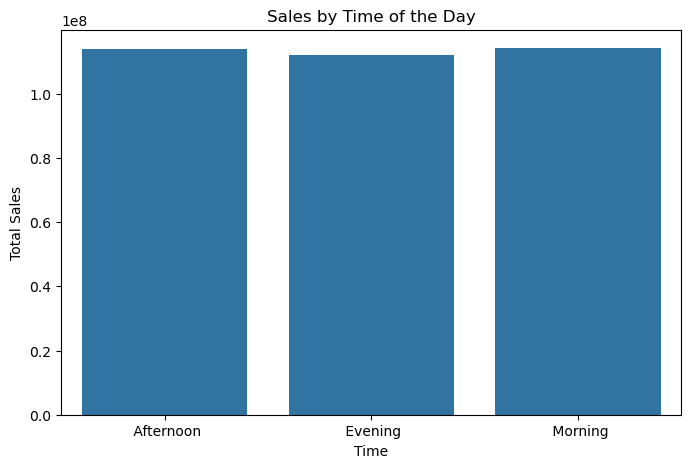

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=time_sales, x="Time", y="Sales")
plt.title("Sales by Time of the Day")
plt.xlabel("Time")
plt.ylabel("Total Sales")
plt.show()

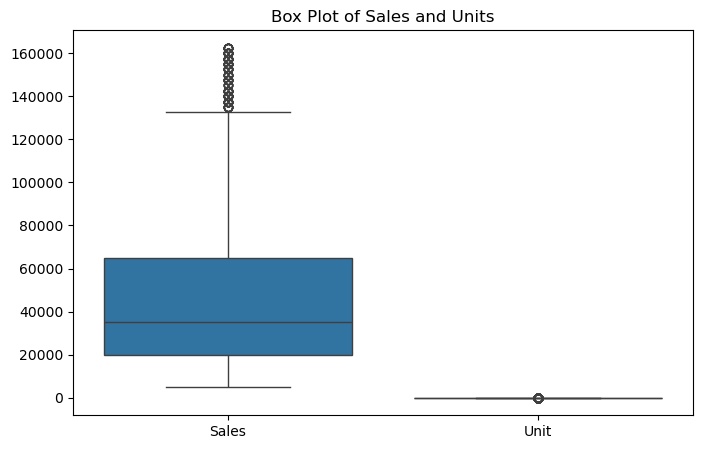

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Sales","Unit"]])
plt.title("Box Plot of Sales and Units")
plt.show()

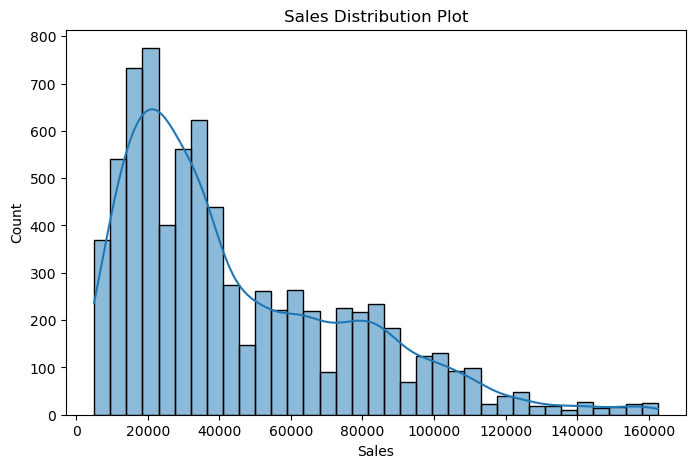

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution Plot")
plt.show()